In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pprint import pprint
from util.load import DataLoader
from util.backtest import Backtest
from util.plot import (
    create_pairwise_scatter_plot,
    create_correlation_matrix,
    plot_backtest_results,
)

In [2]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 100
df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="polysignal"
)
df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-03-25: 100%|██████████| 49/49 [00:00<00:00, 148.90it/s]


,time_to_strike,day_forecast_strike_dev,current_forecast_strike_dev,day_current_forecast_dev,day_wind_gusts_max,day_wind_speed_max,day_cloud_cover_max,day_cloud_cover_min,day_sunshine_duration,hour_wind_gusts,...,yes_price_sentiment_60,count_sentiment_60,yes_price_trend_60,count_agg_120,yes_price_vol_120,count_vol_120,taker_side_sentiment_120,yes_price_sentiment_120,count_sentiment_120,yes_price_trend_120
0,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
1,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
2,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
3,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
4,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4


In [3]:
df.describe()

,time,time_to_strike,day_forecast_strike_dev,current_forecast_strike_dev,day_current_forecast_dev,day_wind_gusts_max,day_wind_speed_max,day_cloud_cover_max,day_cloud_cover_min,day_sunshine_duration,...,yes_price_sentiment_60,count_sentiment_60,yes_price_trend_60,count_agg_120,yes_price_vol_120,count_vol_120,taker_side_sentiment_120,yes_price_sentiment_120,count_sentiment_120,yes_price_trend_120
count,60619,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,...,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000,60619.000000
mean,2025-04-21 14:45:23.884444416,47087.093304,0.029329,-7.240383,7.269712,41.035994,22.150613,93.608209,18.099655,26658.925930,...,35.548001,31.947876,-2.241987,7414.378149,6.996224,53.641057,0.563740,35.041047,30.841201,-3.460367
min,2025-03-24 23:59:21.313972,7.319000,-13.100000,-34.400000,-0.900000,18.400000,14.100000,0.000000,0.000000,0.000000,...,3.000000,1.000000,-93.000000,1.000000,0.000000,0.000000,0.000000,3.000000,1.000000,-87.000000
25%,2025-04-09 08:25:35.937094912,36254.947000,-1.400000,-11.100000,1.900000,33.800000,18.200000,100.000000,0.000000,5345.720000,...,18.316500,15.074000,-8.000000,3498.000000,2.594000,25.209000,0.442000,19.195000,16.250000,-10.000000
50%,2025-04-23 09:33:06.594630912,44653.543000,0.100000,-5.300000,4.500000,41.000000,20.700000,100.000000,0.000000,33584.730000,...,33.301000,24.963000,-1.000000,6099.000000,5.216000,42.272000,0.571000,33.896000,25.225000,-1.000000
75%,2025-05-04 14:22:34.041709568,53772.481000,1.700000,-2.100000,11.500000,47.500000,25.600000,100.000000,14.000000,42544.800000,...,49.041000,40.115000,4.000000,9790.500000,9.745000,65.708000,0.701000,47.561000,38.081000,5.000000
max,2025-05-15 20:20:49.437202,86399.922000,11.100000,6.400000,32.200000,62.600000,36.000000,100.000000,100.000000,47859.230000,...,97.000000,900.000000,85.000000,37019.000000,34.136000,716.283000,1.000000,97.000000,900.000000,78.000000
std,NaN,16694.039436,2.557885,6.902863,7.015806,10.713627,5.277153,22.159641,33.708566,17274.071621,...,21.248997,29.206997,16.816015,5786.943676,5.845429,46.969763,0.209163,19.859412,24.889425,19.364054


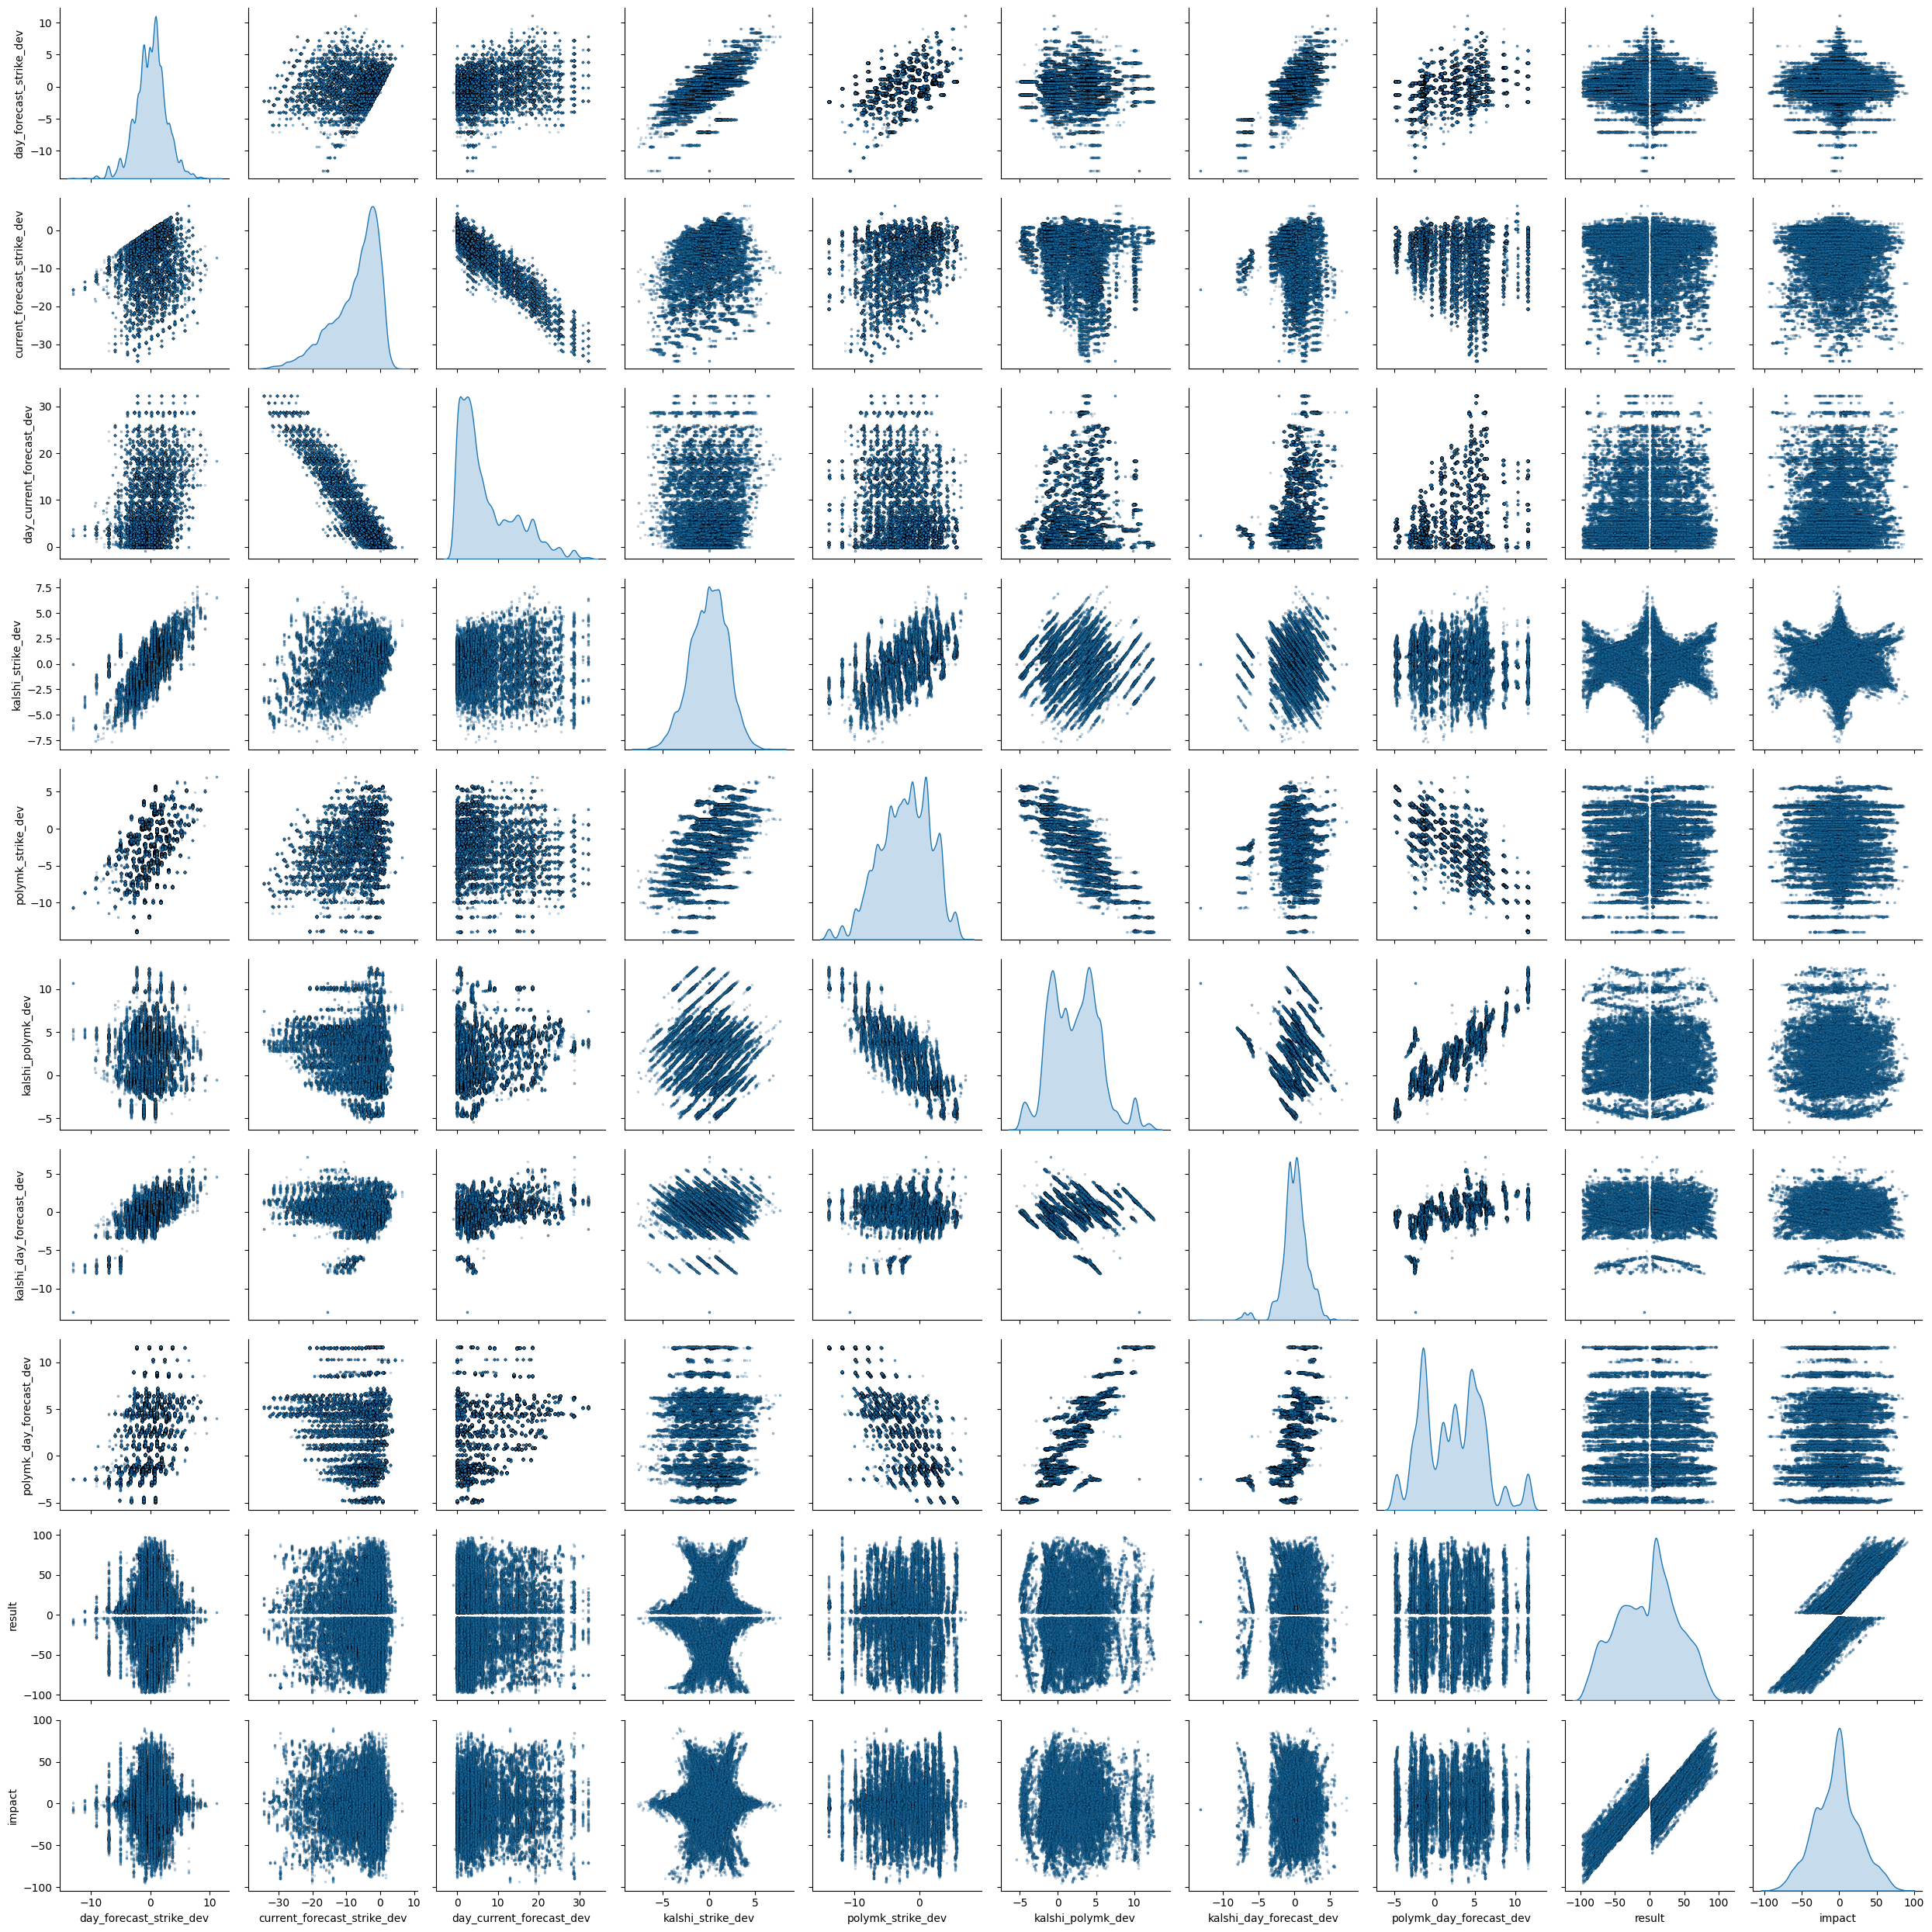

In [4]:
dev_features = [f for f in df.columns if f.endswith("dev")]
create_pairwise_scatter_plot(df, dev_features + ["result", "impact"])

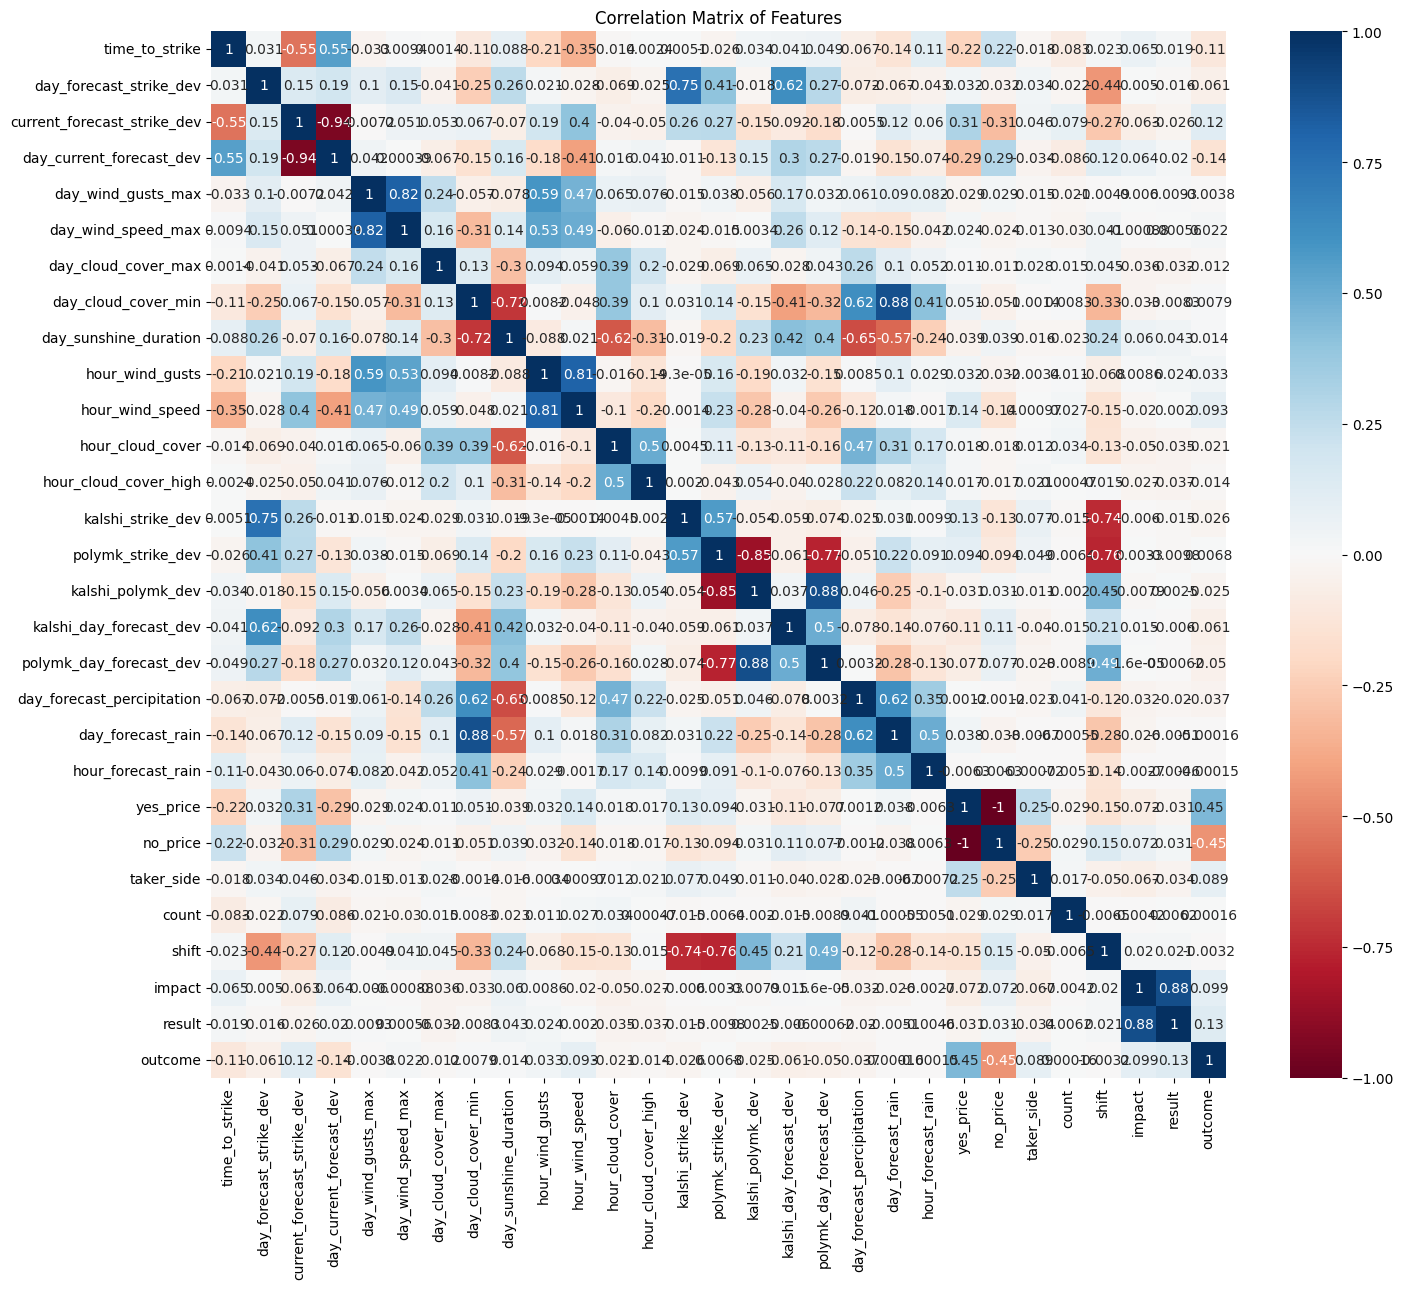

In [5]:
market_features = [
    f
    for f in df.columns.tolist()
    if not f.split("_")[-1].isdigit() and f not in ["time", "ticker", "trade_id"]
]
create_correlation_matrix(df, market_features)

2025-05-05 | R2 train: 0.018289397243777872, R2 test: -0.0651281350184878 | Corr train: 0.13523829811617466, Corr test: 0.0815239700496856
2025-05-06 | R2 train: 0.018632663788988202, R2 test: -0.14714998226459275 | Corr train: 0.13650151582649914, Corr test: 0.05179911068952538
2025-05-07 | R2 train: 0.017380781888815977, R2 test: 0.015476327780374888 | Corr train: 0.13183619351644776, Corr test: 0.16932030559583724
2025-05-08 | R2 train: 0.01744981886512631, R2 test: -0.0030169481947344146 | Corr train: 0.13209776264366727, Corr test: 0.092771630459643
2025-05-10 | R2 train: 0.017299590920806684, R2 test: 0.01533054530808775 | Corr train: 0.1315279094175558, Corr test: 0.12405530861722858
2025-05-11 | R2 train: 0.017371816354113778, R2 test: -0.0208828874127851 | Corr train: 0.13180218662255502, Corr test: 0.023584952706060147
2025-05-12 | R2 train: 0.017173176962194003, R2 test: -0.019460483949720997 | Corr train: 0.131046468853705, Corr test: -0.0031010834902018714
2025-05-13 | R2 

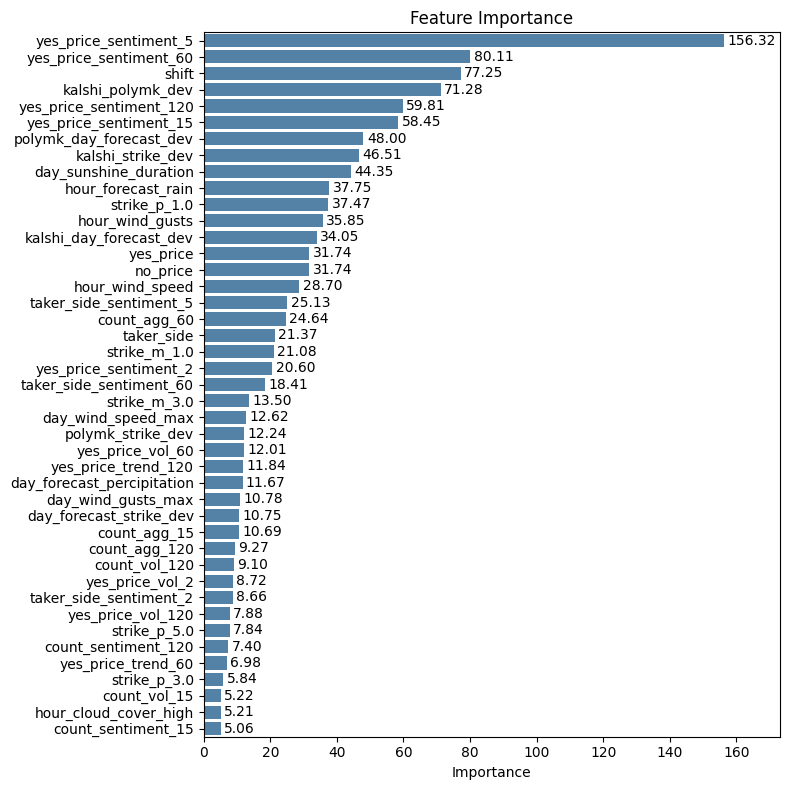

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    QuantileRegressor,
    BayesianRidge,
    Ridge,
)
from sklearn.model_selection import TimeSeriesSplit

# turn time into datetime object


def plot_feature_importances(df, threshold=1):
    df["time"] = pd.to_datetime(df["time"])
    df["date"] = df["time"].dt.date
    exclude = np.array(
        ["time", "result", "impact", "ticker", "trade_id", "outcome", "date"]
    )
    features = np.array([f for f in df.columns.tolist() if f not in exclude])
    tscv = TimeSeriesSplit(n_splits=10, test_size=1)
    feature_importances = np.zeros(len(features))

    for train_index, test_index in tscv.split(df["date"].unique()):
        train_dates, test_dates = (
            df["date"].unique()[train_index],
            df["date"].unique()[test_index],
        )
        train_data, test_data = (
            df[df["date"].isin(train_dates)],
            df[df["date"].isin(test_dates)],
        )

        # scaler = RobustScaler(unit_variance=True)
        scaler = RobustScaler(unit_variance=True)
        train_data[features] = scaler.fit_transform(train_data[features])
        test_data[features] = scaler.transform(test_data[features])
        lasso = Ridge(alpha=0.1)
        lasso.fit(train_data[features], train_data["result"])
        # rf = RandomForestRegressor(n_estimators=100, random_state=42)
        # rf.fit(train_data[features], train_data["result"])
        r2_train = lasso.score(train_data[features], train_data["result"])
        r2_test = lasso.score(test_data[features], test_data["result"])
        corr_train = np.corrcoef(
            lasso.predict(train_data[features]), train_data["result"]
        )[0, 1]
        corr_test = np.corrcoef(
            lasso.predict(test_data[features]), test_data["result"]
        )[0, 1]
        print(
            f"{test_dates[0]} | R2 train: {r2_train}, R2 test: {r2_test} | Corr train: {corr_train}, Corr test: {corr_test}"
        )
        feature_importances += lasso.coef_

    feature_importances = abs(feature_importances)
    sorted_idx = np.argsort(feature_importances)[::-1]
    features, feature_importances = (
        features[sorted_idx],
        feature_importances[sorted_idx],
    )
    features = features[feature_importances > threshold]
    feature_importances_df = pd.DataFrame(
        {
            "Feature": features,
            "Importance": feature_importances[feature_importances > threshold],
        }
    )

    plt.figure(figsize=(8, 8))
    ax = sns.barplot(
        y="Feature", x="Importance", data=feature_importances_df, color="steelblue"
    )
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("")
    for i, bar in enumerate(ax.patches):
        width = bar.get_width()
        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            ha="left",
            va="center",
        )
    current_xlim = plt.xlim()
    plt.xlim(current_xlim[0], current_xlim[1] + 9)
    plt.tight_layout()
    plt.show()


plot_feature_importances(df, threshold=5)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    QuantileRegressor,
    BayesianRidge,
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF


class Model(object):

    def __init__(
        self,
        output_metric: str = "result",
        features: list[str] = None,
        outlier_threshold: float = 0.00,
    ):
        self.output_metric = output_metric
        self.features = features
        self.outlier_threshold = outlier_threshold
        self.pipeline = Pipeline(
            [
                ("robust_scaler", RobustScaler(unit_variance=True)),
                (
                    "quantile_transformer",
                    QuantileTransformer(n_quantiles=100, output_distribution="normal"),
                ),
                (
                    "voting",
                    VotingRegressor(
                        estimators=[
                            (
                                "gb",
                                GradientBoostingRegressor(
                                    n_estimators=50,
                                    learning_rate=0.01,
                                    max_depth=4,
                                    subsample=0.5,
                                    min_samples_split=50,
                                    random_state=42,
                                ),
                            ),
                            (
                                "rf",
                                RandomForestRegressor(
                                    n_estimators=50, max_depth=3, random_state=42
                                ),
                            ),
                            ("lasso", Lasso(alpha=0.1)),
                            ("knn_10", KNeighborsRegressor(n_neighbors=25)),
                        ],
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    def __call__(
        self, train_data: pd.DataFrame, input_data: pd.DataFrame
    ) -> pd.DataFrame:
        if self.features is None:
            self.features = [
                f
                for f in train_data.columns.tolist()
                if (
                    f
                    not in ["time", "result", "impact", "ticker", "trade_id", "outcome"]
                )
            ]
            # print(self.features)
        self.pipeline.fit(train_data[self.features], train_data[self.output_metric])
        input_predictions = self.pipeline.predict(input_data[self.features])
        train_predictions = self.pipeline.predict(train_data[self.features])
        return train_predictions, input_predictions

100%|██████████| 49/49 [04:45<00:00,  5.82s/it]


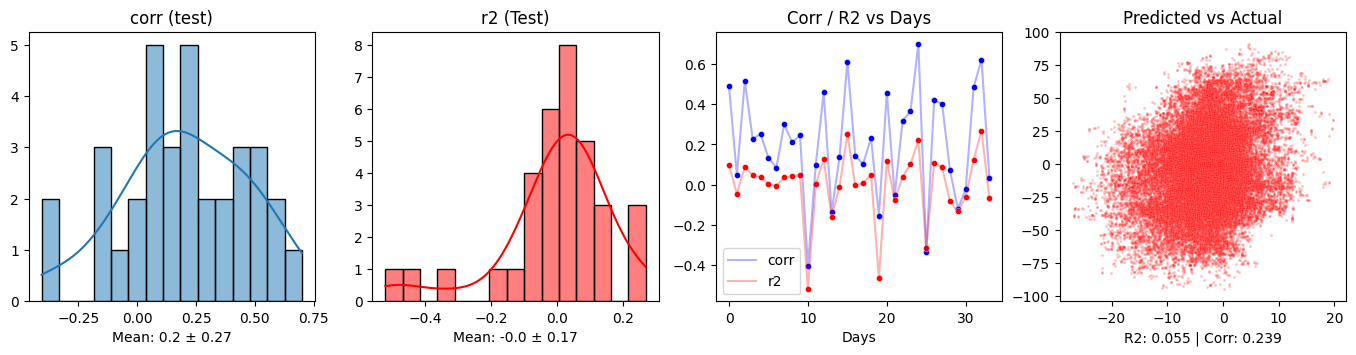

In [7]:
min_window_size, max_window_size, backtest_window = 15, 30, 50

output_metric = "impact"
backtest = Backtest("kxhighny", data_dir="../data", backtest_window=backtest_window)
model = Model(features=None, output_metric=output_metric)

results, predictions, day_predictions, predictions_df = backtest.get_backtest_stats(
    model,
    min_window_size,
    max_window_size,
    output_metric=output_metric,
    # scaler=QuantileTransformer(n_quantiles=100, output_distribution="uniform")
    # scaler=QuantileTransformer(n_quantiles=100, output_distribution="normal")
)
plot_backtest_results(results, predictions)

In [8]:
results[results["corr_test"] > -0.1].mean()

r2_train      0.322214
r2_test       0.052973
corr_train    0.755461
corr_test     0.279206
dtype: float64

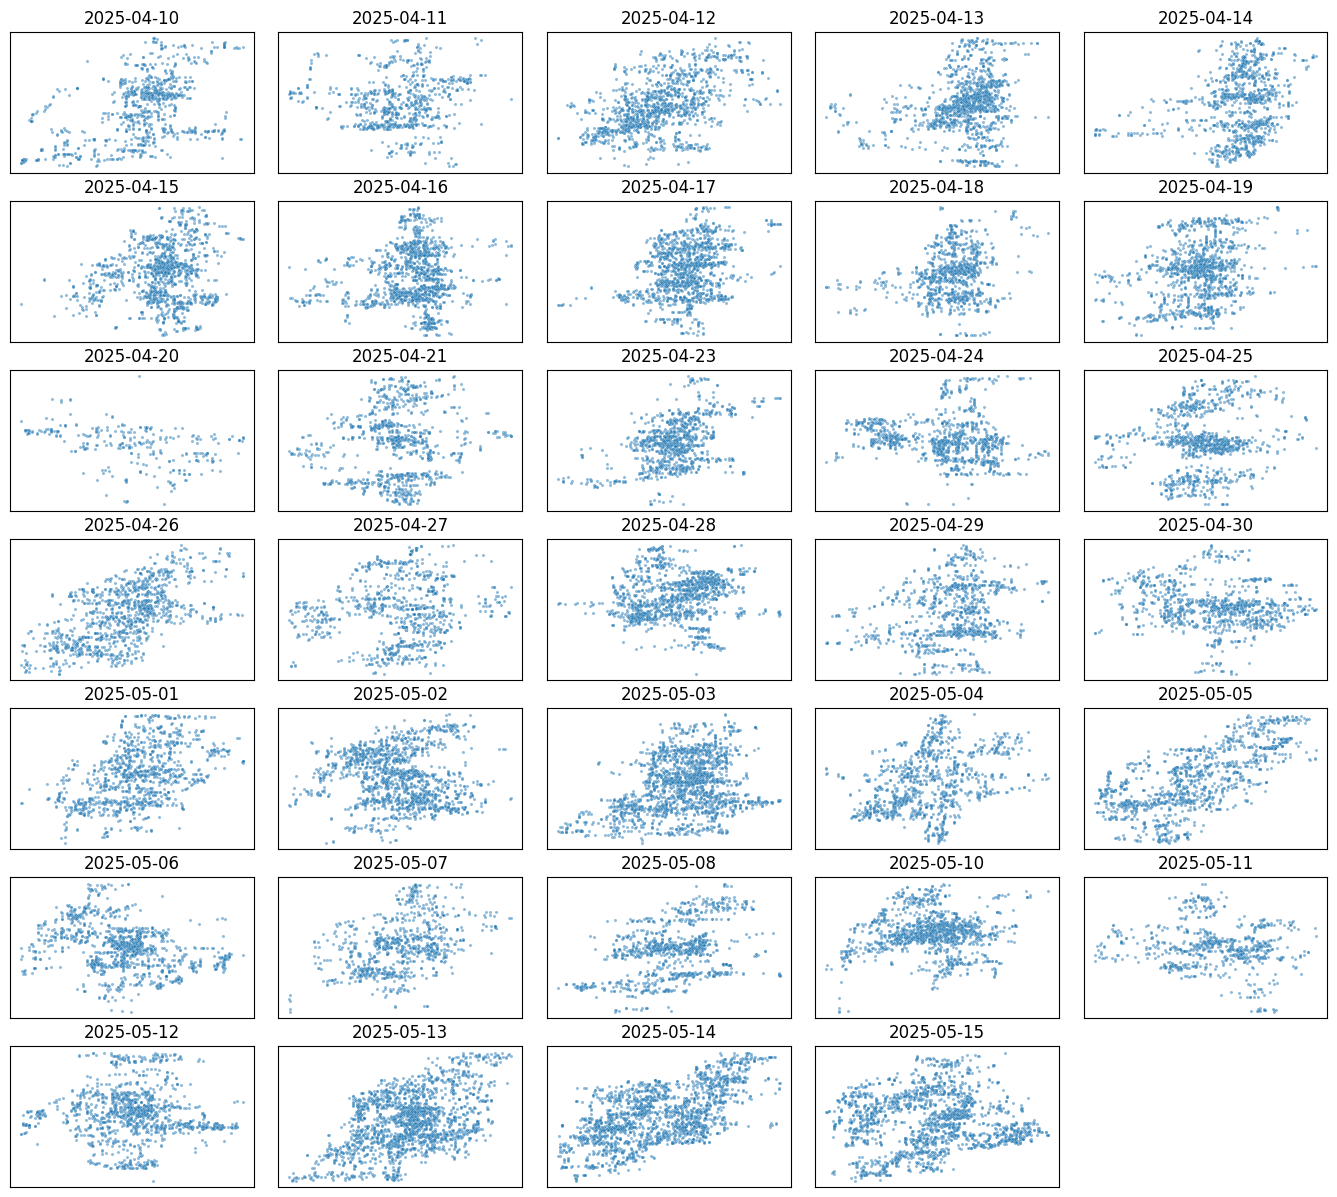

In [9]:
dates = sorted(list(day_predictions.keys()))
fig, axs = plt.subplots(len(dates) // 5 + 1, 5, figsize=(17, 15))

# Add padding between subplots
plt.subplots_adjust(hspace=0.2, wspace=0.1)

for i in range(0, len(dates), 5):
    for idx, date in enumerate(dates[i : i + 5]):
        if i // 5 < axs.shape[0] and idx < axs.shape[1]:  # Check if the subplot exists
            # axs[i//5, idx].scatter(day_predictions[date]["y_pred"], day_predictions[date]["y_real"], alpha=0.5, s=2)
            sns.scatterplot(
                x="y_pred",
                y="y_real",
                data=day_predictions[date],
                ax=axs[i // 5, idx],
                alpha=0.5,
                s=5,
            )
            axs[i // 5, idx].set_title(date)
            axs[i // 5, idx].xaxis.set_visible(False)
            axs[i // 5, idx].yaxis.set_visible(False)

# Hide empty subplots in the last row
for i in range(len(dates), (len(dates) // 5 + 1) * 5):
    row = i // 5
    col = i % 5
    if row < axs.shape[0] and col < axs.shape[1]:
        axs[row, col].set_visible(False)
plt.show()

In [11]:
np.mean(predictions_df[predictions_df["taker_side"] == 1]["result"])
np.mean(predictions_df[predictions_df["taker_side"] == 0]["result"])

np.float64(-1.1057639809687232)

In [12]:
create_correlation_matrix(predictions_df, market_features + ["result", "result_pred"])

KeyError: "['result_pred'] not in index"